<a href="https://colab.research.google.com/github/vikranthrach/Capstone-Project/blob/main/Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 — Titanic EDA

This notebook performs Tasks 1–6. The raw Titanic dataset is loaded with
`sns.load_dataset("titanic")` exactly once and immediately saved as
`titanic.csv`. The saved CSV is the offline fallback used by the modeling notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

os.makedirs("charts", exist_ok=True)
sns.set_theme(style="whitegrid")

## Task 1 — Load, save offline fallback, and profile

In [2]:
# The ONE raw network/cache load for this module
df = sns.load_dataset("titanic")

# Immediately save the raw loaded DataFrame as the committed offline fallback
df.to_csv("titanic.csv", index=False)

print("Raw dataset loaded once and saved to titanic.csv")

Raw dataset loaded once and saved to titanic.csv


In [3]:
print("----- INFO -----")
df.info()

print("\n----- DESCRIBE -----")
print(df.describe())

print("\n----- SHAPE -----")
print(df.shape)

----- INFO -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

----- DESCRIBE -----
         survived      pclass         ag

In [4]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_pct
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]

print(missing_summary)

             missing_count  missing_percentage
age                    177               19.87
embarked                 2                0.22
deck                   688               77.22
embark_town              2                0.22


## Task 2 — Missing-value handling

The measured missing percentages are reported above. The rule is:
- under 5%: drop affected rows;
- 5%–30%: impute;
- very high missingness: drop the column when reliable imputation is not defensible.

For this Titanic dataset, `age` is imputed with the median because it falls in the
5%–30% band. `embarked` and `embark_town` are handled by dropping their very small
number of incomplete rows. `deck` is dropped because its missingness is very high.

In [5]:
# Keep a cleaned EDA DataFrame separate from the raw offline fallback.
eda_df = df.copy()

# High missingness: unreliable to impute
eda_df = eda_df.drop(columns=["deck"])

# 5%–30%: median imputation
eda_df["age"] = eda_df["age"].fillna(eda_df["age"].median())

# Under 5%: drop affected rows
eda_df = eda_df.dropna(subset=["embarked", "embark_town"]).reset_index(drop=True)

print("Missing values after EDA cleaning:")
print(eda_df.isna().sum())

Missing values after EDA cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


## Task 3 — Univariate analysis

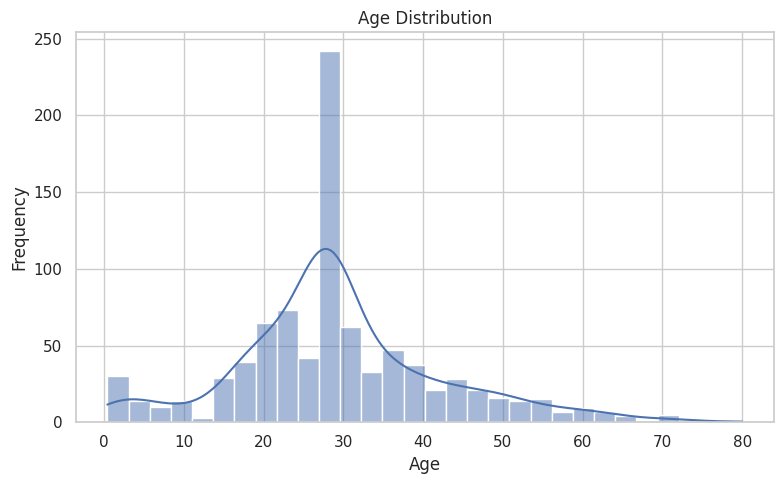

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=eda_df, x="age", bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("charts/age_hist.png", dpi=150)
plt.show()

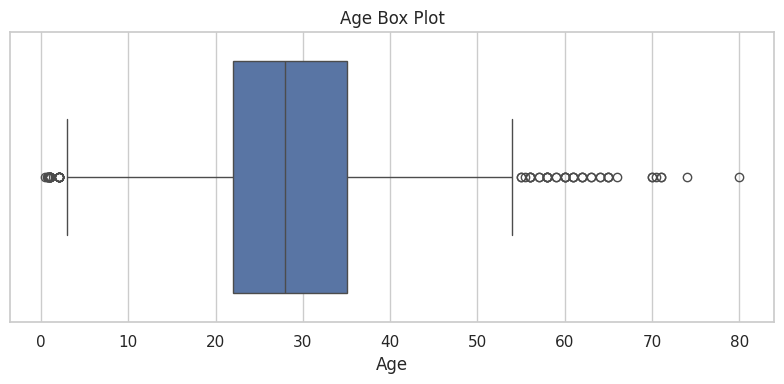

In [7]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=eda_df, x="age")
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.tight_layout()
plt.savefig("charts/age_box.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=eda_df, x="fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("charts/fare_hist.png", dpi=150)
plt.show()

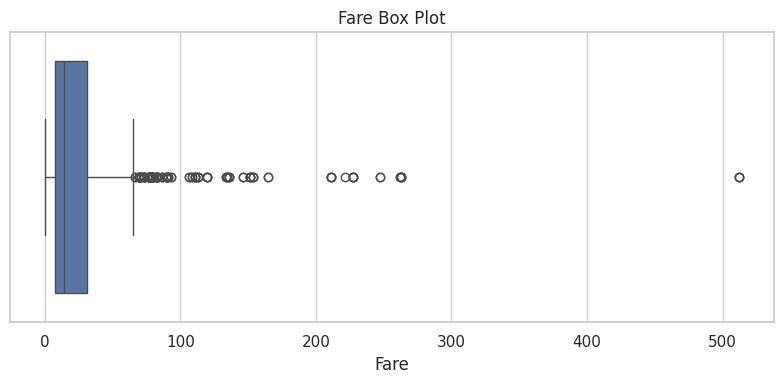

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=eda_df, x="fare")
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.tight_layout()
plt.savefig("charts/fare_box.png", dpi=150)
plt.show()

In [9]:
def iqr_outlier_summary(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[column] < lower) | (data[column] > upper)
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum())
    }

age_iqr = iqr_outlier_summary(eda_df, "age")
fare_iqr = iqr_outlier_summary(eda_df, "fare")

print("AGE IQR RESULTS")
print(age_iqr)

print("\nFARE IQR RESULTS")
print(fare_iqr)

AGE IQR RESULTS
{'Q1': np.float64(22.0), 'Q3': np.float64(35.0), 'IQR': np.float64(13.0), 'lower_bound': np.float64(2.5), 'upper_bound': np.float64(54.5), 'outlier_count': 65}

FARE IQR RESULTS
{'Q1': np.float64(7.8958), 'Q3': np.float64(31.0), 'IQR': np.float64(23.1042), 'lower_bound': np.float64(-26.7605), 'upper_bound': np.float64(65.6563), 'outlier_count': 114}


In [10]:
fare_mean = eda_df["fare"].mean()
fare_median = eda_df["fare"].median()
fare_mode = eda_df["fare"].mode().iloc[0]

print(f"Fare mean   : {fare_mean:.4f}")
print(f"Fare median : {fare_median:.4f}")
print(f"Fare mode   : {fare_mode:.4f}")
print(f"Ordering    : mean={fare_mean:.4f}, median={fare_median:.4f}, mode={fare_mode:.4f}")

if fare_mean > fare_median > fare_mode:
    skew_conclusion = "right-skewed"
elif fare_mean < fare_median < fare_mode:
    skew_conclusion = "left-skewed"
else:
    skew_conclusion = "not clearly classified by mean/median/mode ordering"

print("Conclusion:", skew_conclusion)

Fare mean   : 32.0967
Fare median : 14.4542
Fare mode   : 8.0500
Ordering    : mean=32.0967, median=14.4542, mode=8.0500
Conclusion: right-skewed


**Fare interpretation:** The fare distribution is expected to be right-skewed when
the mean is above the median and the mode. A relatively small number of high fares
pulls the mean toward the upper tail.

## Task 4 — Bivariate analysis

In [11]:
# Survival rate by sex
male = eda_df[eda_df["sex"] == "male"]
female = eda_df[eda_df["sex"] == "female"]

print(f"Male survival rate   : {male['survived'].mean():.2%}")
print(f"Female survival rate : {female['survived'].mean():.2%}")

# Explicit boolean masking with &
male_survivors = eda_df[(eda_df["sex"] == "male") & (eda_df["survived"] == 1)]
female_survivors = eda_df[(eda_df["sex"] == "female") & (eda_df["survived"] == 1)]

print("Male survivors:", len(male_survivors))
print("Female survivors:", len(female_survivors))

Male survival rate   : 18.89%
Female survival rate : 74.04%
Male survivors: 109
Female survivors: 231


In [12]:
print("Survival rate by passenger class:")
for pclass in sorted(eda_df["pclass"].unique()):
    subset = eda_df[eda_df["pclass"] == pclass]
    print(f"Class {pclass}: {subset['survived'].mean():.2%}")

Survival rate by passenger class:
Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%


In [13]:
print("Survival rate by sex and passenger class:")
for sex in sorted(eda_df["sex"].unique()):
    for pclass in sorted(eda_df["pclass"].unique()):
        subset = eda_df[
            (eda_df["sex"] == sex) &
            (eda_df["pclass"] == pclass)
        ]
        print(f"{sex}, class {pclass}: {subset['survived'].mean():.2%}")

Survival rate by sex and passenger class:
female, class 1: 96.74%
female, class 2: 92.11%
female, class 3: 50.00%
male, class 1: 36.89%
male, class 2: 15.74%
male, class 3: 13.54%


In [14]:
correlation_columns = [
    "survived", "pclass", "age", "sibsp", "parch", "fare"
]

corr_matrix = eda_df[correlation_columns].corr()
print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


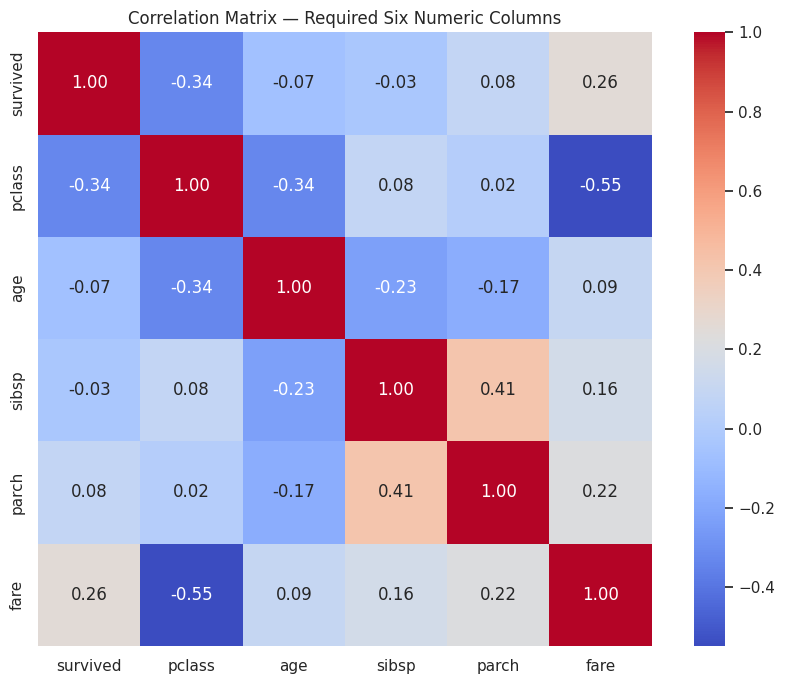

In [15]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix — Required Six Numeric Columns")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=150)
plt.show()

In [16]:
# Find the two strongest off-diagonal pairs by absolute correlation.
pairs = []
for i, col1 in enumerate(correlation_columns):
    for j, col2 in enumerate(correlation_columns):
        if i < j:
            value = corr_matrix.loc[col1, col2]
            pairs.append((col1, col2, value, abs(value)))

top_two = sorted(pairs, key=lambda x: x[3], reverse=True)[:2]

print("Two strongest correlation pairs:")
for col1, col2, value, abs_value in top_two:
    print(f"{col1} <-> {col2}: correlation={value:.4f}, absolute={abs_value:.4f}")

Two strongest correlation pairs:
pclass <-> fare: correlation=-0.5482, absolute=0.5482
sibsp <-> parch: correlation=0.4145, absolute=0.4145


**Correlation interpretation:** The two pairs printed above are the two feature pairs
with the largest absolute off-diagonal correlation coefficients. The sign indicates
direction, while the magnitude indicates the strength of the linear association.
Correlation describes association and does not by itself establish causation.

## Task 5 — Multivariate data story

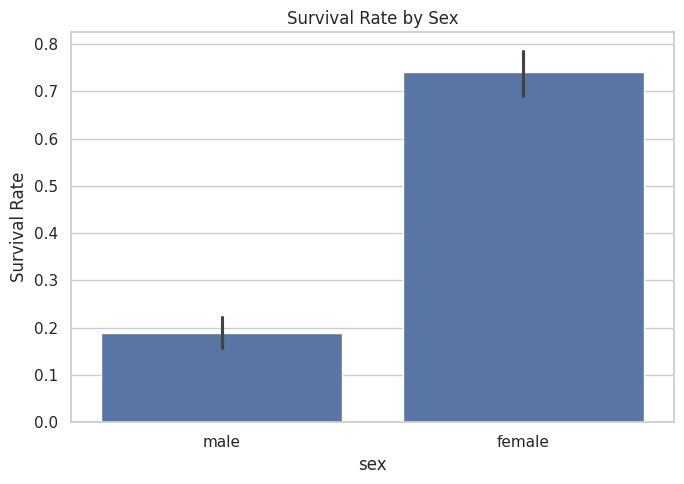

In [17]:
plt.figure(figsize=(7, 5))
sns.barplot(data=eda_df, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("charts/survival_by_sex.png", dpi=150)
plt.show()

**Interpretation:** Survival rates differ substantially by sex in this dataset.
Female passengers have a much higher observed survival rate than male passengers.
Sex is therefore an important descriptive factor in the survival pattern.

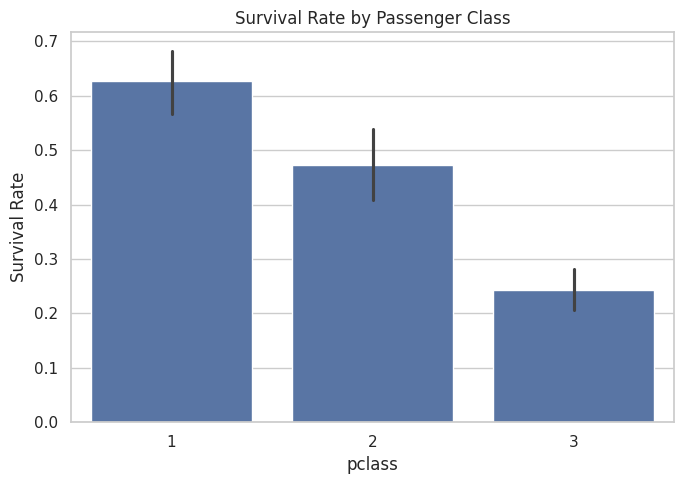

In [18]:
plt.figure(figsize=(7, 5))
sns.barplot(data=eda_df, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("charts/survival_by_pclass.png", dpi=150)
plt.show()

**Interpretation:** Survival rates vary across passenger classes.
First-class passengers have the highest observed survival rate, while third-class
passengers have the lowest. Passenger class therefore provides another clear
dimension for understanding survival.

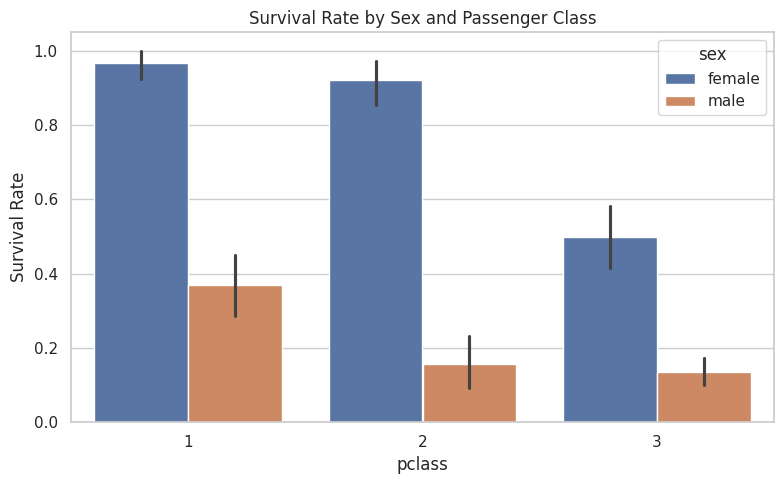

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=eda_df, x="pclass", y="survived", hue="sex")
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("charts/survival_sex_pclass.png", dpi=150)
plt.show()

**Interpretation:** Combining sex and passenger class reveals a stronger pattern than
either variable alone. Female passengers generally have higher survival rates across
classes, while male passengers in third class have particularly low observed survival.

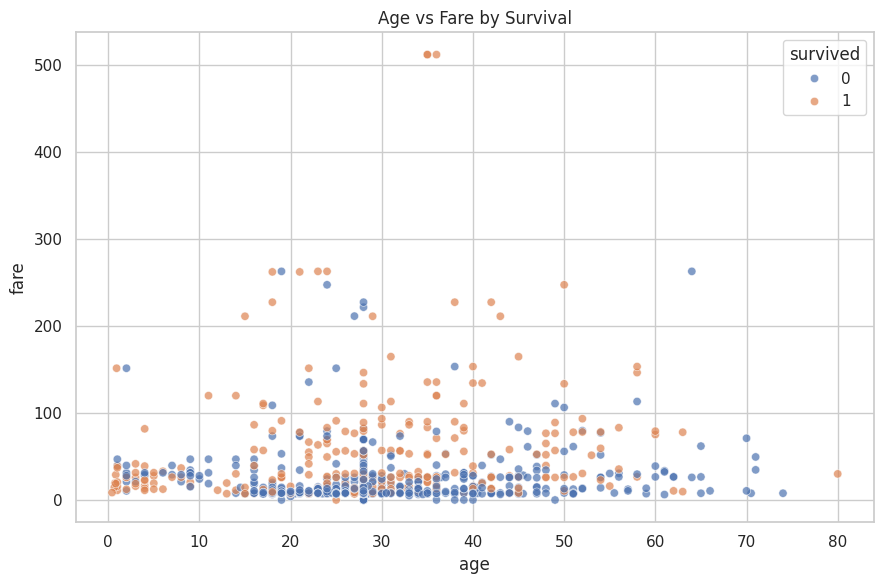

In [20]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=eda_df, x="age", y="fare", hue="survived", alpha=0.7)
plt.title("Age vs Fare by Survival")
plt.tight_layout()
plt.savefig("charts/age_fare_survival.png", dpi=150)
plt.show()

**Interpretation:** The scatter plot shows how age and fare vary for survivors and
non-survivors. Higher fares are concentrated in particular passenger groups, and
survival status varies across the age/fare space. This supports using multiple
passenger characteristics together rather than relying on a single feature.

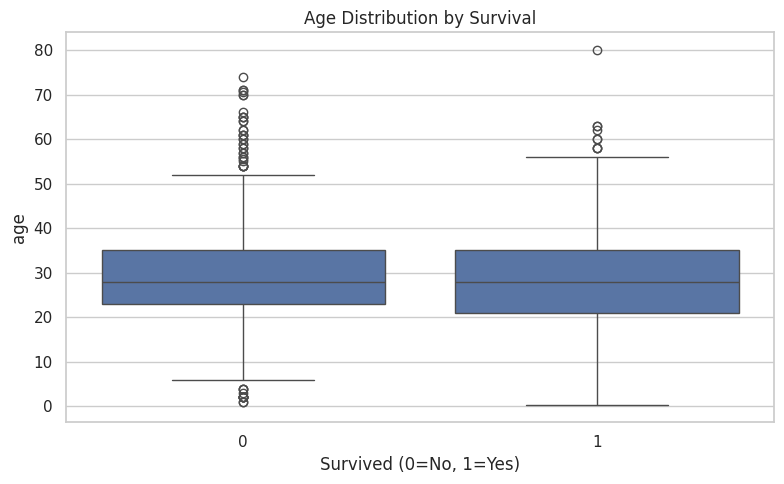

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_df, x="survived", y="age")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0=No, 1=Yes)")
plt.tight_layout()
plt.savefig("charts/age_survival_box.png", dpi=150)
plt.show()

**Interpretation:** The age distributions of survivors and non-survivors overlap,
so age alone does not perfectly separate the two groups. However, differences in
the distributions can still provide useful predictive information when age is
combined with other variables.

## Task 6 — Exploratory standardization sanity check

In [ ]:
print("Before standardization")
print(eda_df[["age", "fare"]].agg(["mean", "std"]).T)

In [22]:
standardizer = StandardScaler()
standardized = eda_df.copy()

standardized[["age", "fare"]] = standardizer.fit_transform(
    standardized[["age", "fare"]]
)

comparison = pd.DataFrame({
    "feature": ["age", "fare"],
    "before_mean": [eda_df["age"].mean(), eda_df["fare"].mean()],
    "before_std": [eda_df["age"].std(ddof=0), eda_df["fare"].std(ddof=0)],
    "after_mean": [standardized["age"].mean(), standardized["fare"].mean()],
    "after_std": [standardized["age"].std(ddof=0), standardized["fare"].std(ddof=0)]
})

print(comparison)

  feature  before_mean  before_std    after_mean  after_std
0     age    29.315152   12.977627  2.717486e-16        1.0
1    fare    32.096681   49.669545  1.398706e-16        1.0


**Interpretation:** Standardization transforms `age` and `fare` to approximately
zero mean and unit standard deviation. This is only an EDA-stage sanity check.
The modeling notebook performs its own train-only scaling inside a pipeline so that
test-set information does not leak into preprocessing.

# Module 2 — Titanic Predictive Modeling


In [23]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
os.makedirs("charts", exist_ok=True)
sns.set_theme(style="whitegrid")

## Load the same committed CSV

In [24]:
df = pd.read_csv("titanic.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### Modeling cleaning choice

For classification, the model pipeline will handle missing values rather than
manually imputing them before the split. `deck` is excluded because approximately
77% of it is missing and reliable imputation would be difficult. `alive` is also
excluded because it directly duplicates the target `survived`. `class` duplicates
`pclass`, so it is excluded to avoid redundant representation.

In [25]:
model_df = df.drop(columns=["deck", "alive", "class"], errors="ignore").copy()

# The target must be complete in this dataset.
model_df = model_df.dropna(subset=["survived"]).reset_index(drop=True)

X = model_df.drop(columns=["survived"])
y = model_df["survived"].astype(int)

print("Class balance:")
print(y.value_counts())
print(y.value_counts(normalize=True).rename("proportion"))

Class balance:
survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## Task 7 — Stratified train/test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True))

Train shape: (712, 11)
Test shape : (179, 11)

Train class proportions:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test class proportions:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


**Why stratification?** The target contains two classes with unequal frequencies.
Stratification preserves approximately the same survived/not-survived proportion
in both train and test sets, making the evaluation more representative.

## Task 8 — Train-only preprocessing

In [27]:
numeric_features = [
    "age", "sibsp", "parch", "fare"
]

categorical_features = [
    "sex", "embarked"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Task 9 — Three classifiers

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

pipelines = {}

for name, estimator in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.


### Decision Tree visualization

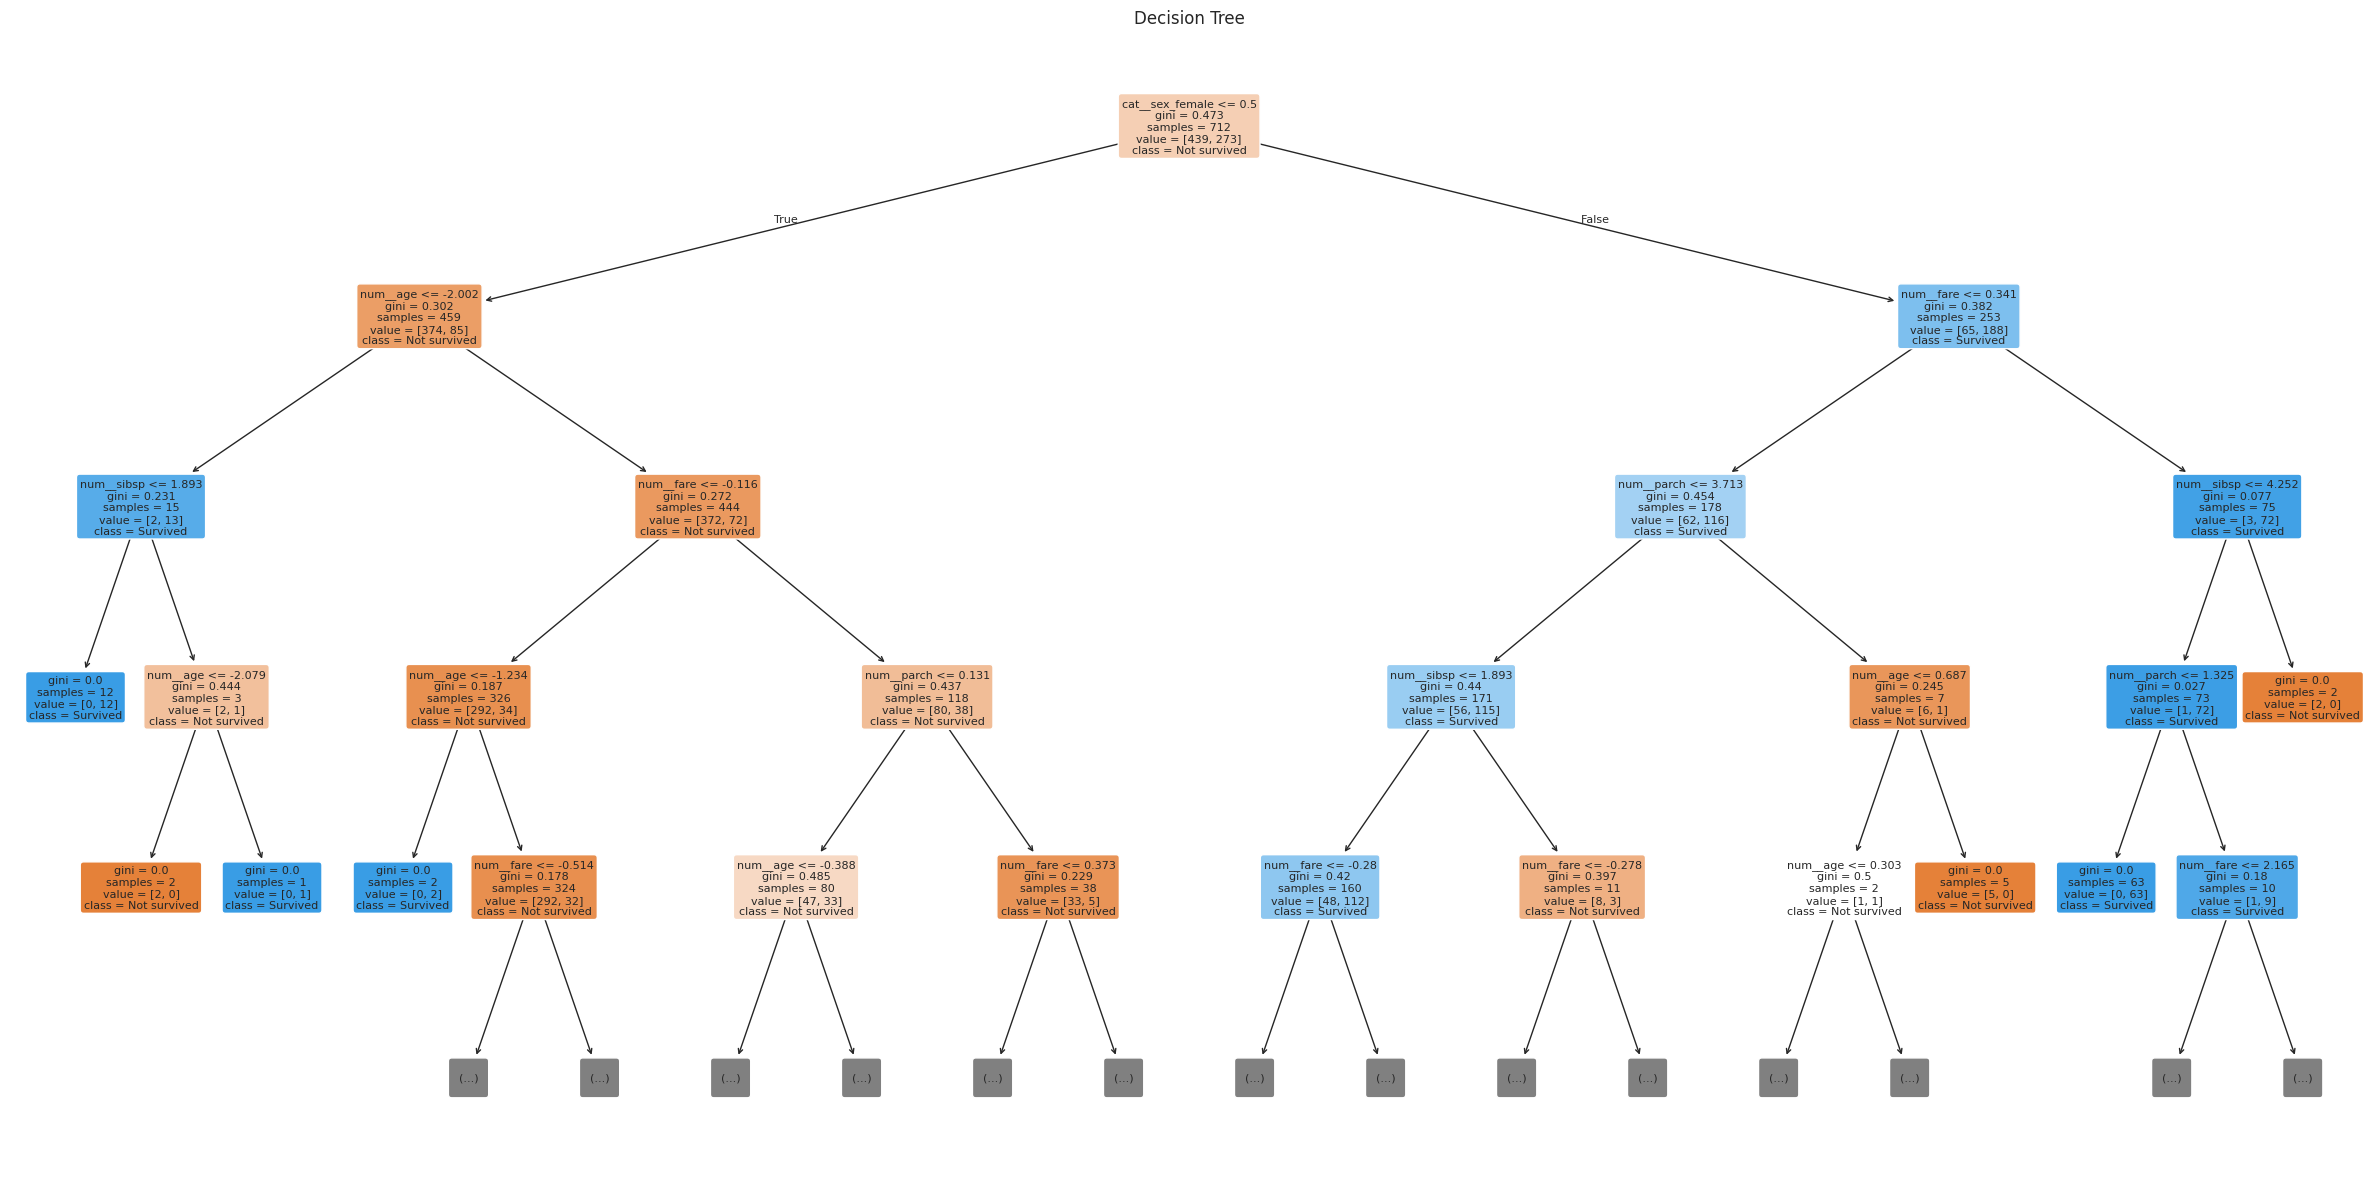

In [29]:
tree_pipe = pipelines["Decision Tree"]

fitted_preprocessor = tree_pipe.named_steps["preprocessor"]
tree_model = tree_pipe.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8
)
plt.title("Decision Tree")
plt.tight_layout()
plt.savefig("charts/decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 10 — Classification evaluation

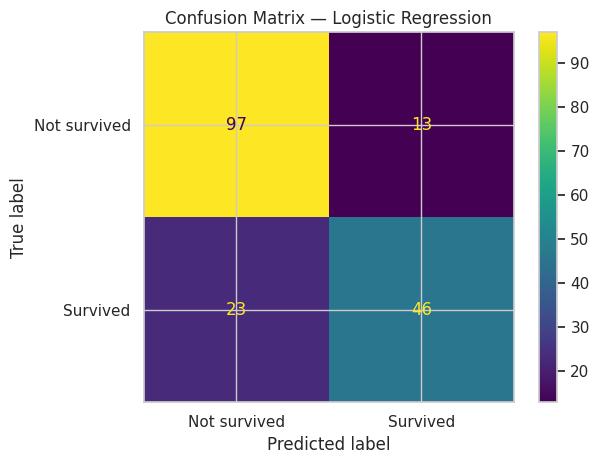

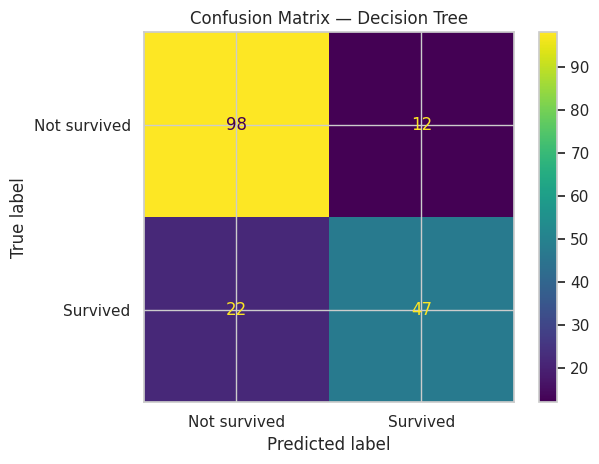

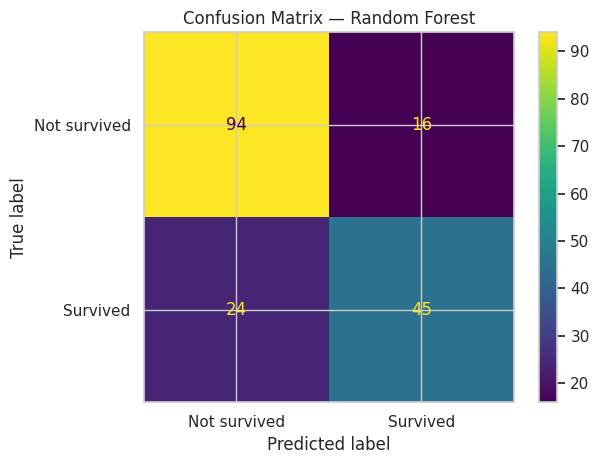

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.798883,0.779661,0.666667,0.718750,0.819368
1,Decision Tree,0.810056,0.796610,0.681159,0.734375,0.830896
2,Random Forest,0.776536,0.737705,0.652174,0.692308,0.824045


In [30]:
results = []
roc_data = {}

for name, pipe in pipelines.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    auc = roc_auc_score(y_test, proba)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    roc_data[name] = (y_test, proba)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not survived", "Survived"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_")
    plt.savefig(f"charts/{safe_name}_confusion_matrix.png", dpi=150)
    plt.show()

classification_results = pd.DataFrame(results)
classification_results

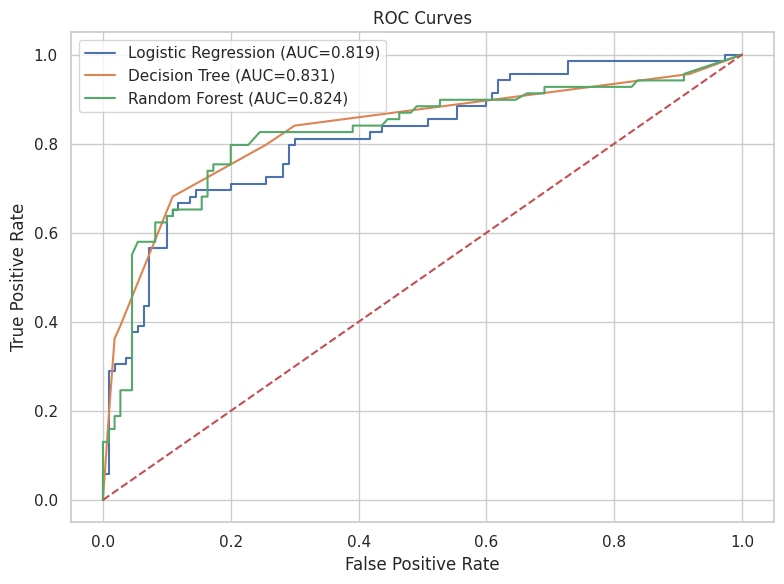

In [31]:
plt.figure(figsize=(8, 6))

for name, (actual, proba) in roc_data.items():
    fpr, tpr, _ = roc_curve(actual, proba)
    auc = roc_auc_score(actual, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig("charts/roc_curves.png", dpi=150)
plt.show()

## Task 11 — Class imbalance comparison

In [32]:
imbalance_rows = []

# Baseline
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)

imbalance_rows.append({
    "Strategy": "Baseline",
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1": f1_score(y_test, pred, zero_division=0)
})

# Class-weighted model
weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])
weighted.fit(X_train, y_train)
pred = weighted.predict(X_test)

imbalance_rows.append({
    "Strategy": "class_weight='balanced'",
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1": f1_score(y_test, pred, zero_division=0)
})

# SMOTE must happen after preprocessing and only on training data.
smote_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
smote_pipe.fit(X_train, y_train)
pred = smote_pipe.predict(X_test)

imbalance_rows.append({
    "Strategy": "SMOTE",
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1": f1_score(y_test, pred, zero_division=0)
})

imbalance_results = pd.DataFrame(imbalance_rows)
print(imbalance_results.to_string(index=False))

               Strategy  Precision   Recall       F1
               Baseline   0.779661 0.666667 0.718750
class_weight='balanced'   0.738462 0.695652 0.716418
                  SMOTE   0.738462 0.695652 0.716418


**Imbalance conclusion:** Compare the three rows above using precision, recall,
and F1 rather than assuming that one strategy is always best. A balanced class
weight or SMOTE approach may improve recall while reducing precision. The final
written conclusion should describe the observed trade-off using the actual values.
SMOTE is applied only within the training pipeline, so the test set remains untouched.

## Task 12 — Random Forest GridSearchCV and OOB score

In [33]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print("\nBest CV F1:")
print(grid.best_score_)

best_rf = grid.best_estimator_
print("\nOOB score:")
print(best_rf.named_steps["model"].oob_score_)

Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

Best CV F1:
0.7489721626558163

OOB score:
0.8103932584269663


## Task 13 — Regression: predict fare

In [34]:
regression_df = df.drop(columns=["deck", "alive", "class"], errors="ignore").copy()
regression_df = regression_df.dropna(subset=["fare"]).reset_index(drop=True)

X_reg = regression_df.drop(columns=["fare"])
y_reg = regression_df["fare"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

reg_numeric = [
    "survived", "pclass", "age", "sibsp", "parch"
]
reg_categorical = [
    "sex", "embarked"
]

reg_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), reg_numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), reg_categorical)
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_pipeline.fit(Xr_train, yr_train)
fare_pred = regression_pipeline.predict(Xr_test)

mae = mean_absolute_error(yr_test, fare_pred)
rmse = np.sqrt(mean_squared_error(yr_test, fare_pred))
r2 = r2_score(yr_test, fare_pred)

n = len(yr_test)
p = regression_pipeline.named_steps["preprocessor"].transform(Xr_test).shape[1]

if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan

print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"R2         : {r2:.4f}")
print(f"Adjusted R2: {adjusted_r2:.4f}")

MAE        : 20.8977
RMSE       : 30.5328
R2         : 0.3975
Adjusted R2: 0.3617


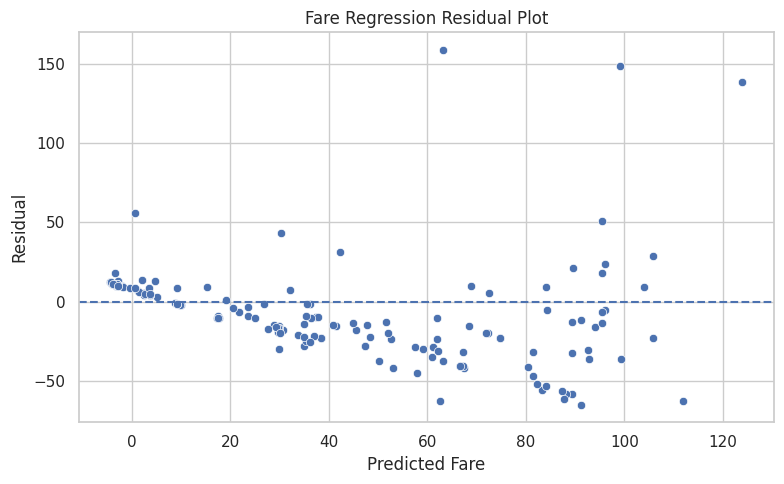

In [35]:
residuals = yr_test - fare_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fare_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Fare Regression Residual Plot")
plt.tight_layout()
plt.savefig("charts/regression_residuals.png", dpi=150)
plt.show()

## Task 14 — Final model comparison

In [36]:
final_classification = classification_results.copy()

# Add regression metrics as a separate group rather than mixing scales.
regression_metrics = pd.DataFrame([{
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted_R2": adjusted_r2
}])

print("CLASSIFICATION METRICS")
print(final_classification.to_string(index=False))

print("\nREGRESSION METRICS")
print(regression_metrics.to_string(index=False))

CLASSIFICATION METRICS
              Model  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.798883   0.779661 0.666667 0.718750 0.819368
      Decision Tree  0.810056   0.796610 0.681159 0.734375 0.830896
      Random Forest  0.776536   0.737705 0.652174 0.692308 0.824045

REGRESSION METRICS
      MAE      RMSE       R2  Adjusted_R2
20.897718 30.532803 0.397548     0.361688


## Task 15 — Save and reload the complete pipeline

In [37]:
# Use the tuned Random Forest pipeline as the deployable classifier.
full_pipeline = best_rf

joblib.dump(full_pipeline, "titanic_pipeline.joblib")
print("Saved:", os.path.abspath("titanic_pipeline.joblib"))

Saved: /content/titanic_pipeline.joblib


In [38]:
# Reload and verify the complete pipeline accepts raw/unprocessed input.
loaded_pipeline = joblib.load("titanic_pipeline.joblib")

raw_sample = X_test.iloc[[0]].copy()
expected = y_test.iloc[0]
prediction = loaded_pipeline.predict(raw_sample)[0]

print("Raw input:")
print(raw_sample)
print("Prediction:", prediction)
print("Actual:", expected)
print("Prediction correct:", prediction == expected)

Raw input:
     pclass   sex   age  sibsp  parch   fare embarked  who  adult_male  \
565       3  male  24.0      2      0  24.15        S  man        True   

     embark_town  alone  
565  Southampton  False  
Prediction: 0
Actual: 0
Prediction correct: True
